In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [190]:
df = pd.read_csv('Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv')

In [191]:
df

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...
...,...,...,...,...,...
26867,BL,I am waiting for a rebate of {{Refund Amount}}...,REFUND,track_refund,Thank you for sharing your situation regarding...
26868,BIL,how to see if there is anything wrong with my ...,REFUND,track_refund,Ensuring the accuracy of your restitution is o...
26869,BLQZ,I'm waiting for a reimbjrsement of {{Currency ...,REFUND,track_refund,"Firstly, I genuinely understand the importance..."
26870,BL,I don't know what to do to see my reimbursemen...,REFUND,track_refund,I've understood you're unsure about how to che...


In [192]:
df.shape

(26872, 5)

In [193]:
df.isnull().sum()

flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

In [194]:
df.dtypes

flags          object
instruction    object
category       object
intent         object
response       object
dtype: object

In [195]:
df["instruction"] = df["instruction"].astype(str).str.strip()

df = df[df["instruction"] != ""]

In [196]:
df["response"] = df["response"].astype(str).str.strip()
df = df[df["response"] != ""]

In [197]:
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [198]:
import re
def clean_text(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '',text)
    
    text = re.sub(r'\d+', '', text)
    
    text = text.lower()  # Convert to lowercase
    
    text = text.strip()  # Remove leading and trailing whitespace
    return text
df['instruction'] = df['instruction'].apply(clean_text)
df['response'] = df['response'].apply(clean_text)

In [199]:
df.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order order number,ORDER,cancel_order,ive understood you have a question regarding c...
1,BQZ,i have a question about cancelling oorder orde...,ORDER,cancel_order,ive been informed that you have a question abo...
2,BLQZ,i need help cancelling puchase order number,ORDER,cancel_order,i can sense that youre seeking assistance with...
3,BL,i need to cancel purchase order number,ORDER,cancel_order,i understood that you need assistance with can...
4,BCELN,i cannot afford this order cancel purchase ord...,ORDER,cancel_order,im sensitive to the fact that youre facing fin...


In [200]:
numeric_df = pd.DataFrame({
    "instruction_length": df["instruction"].str.split().str.len(),
    "response_length": df["response"].str.split().str.len(),
    "category_code": df["category"].astype("category").cat.codes,
    "intent_code": df["intent"].astype("category").cat.codes
})

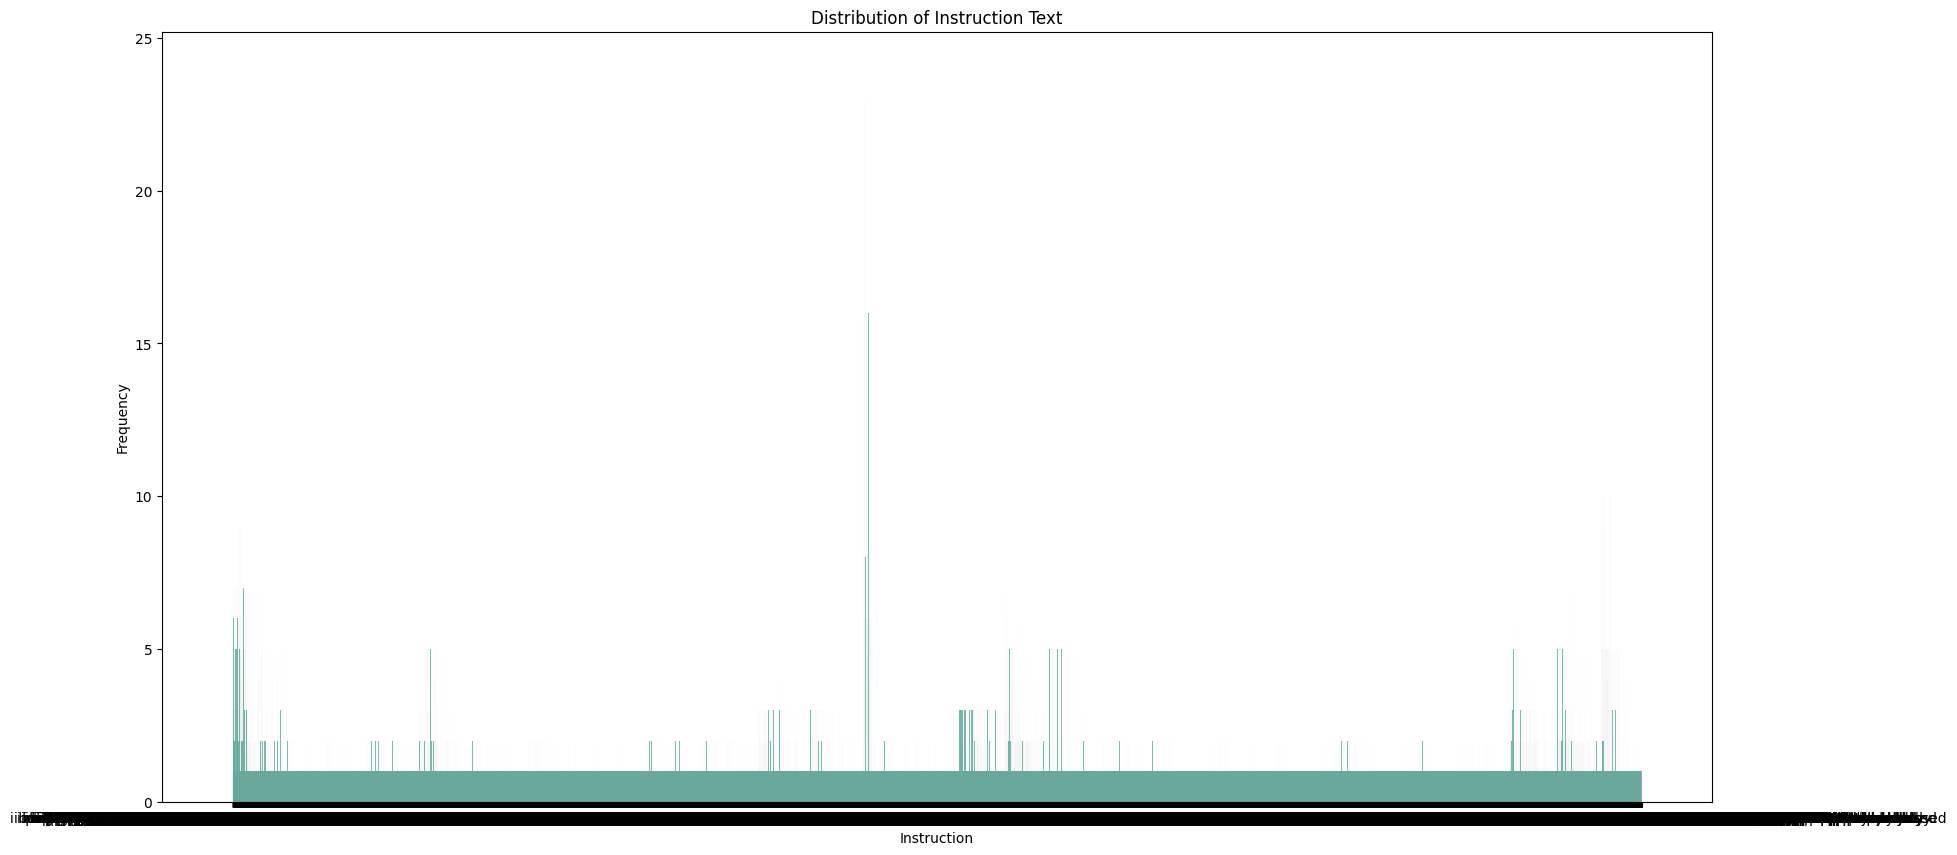

In [201]:
plt.figure(figsize=(20, 10))
sns.histplot(df['instruction'],bins = 30, kde = False)
plt.title('Distribution of Instruction Text')
plt.xlabel('Instruction')
plt.ylabel('Frequency')
plt.show()

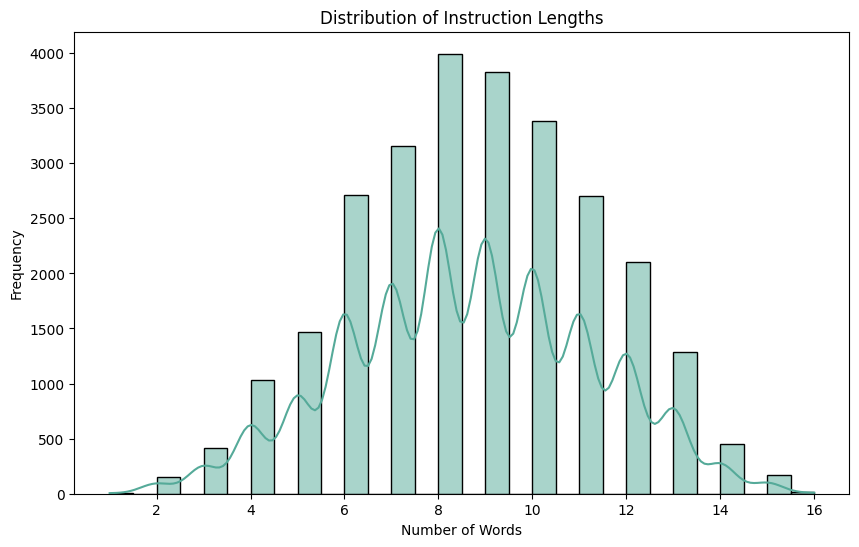

In [202]:
plt.figure(figsize=(10, 6))
sns.histplot(df['instruction'].str.split().apply(len), bins=30, kde=True)
plt.title('Distribution of Instruction Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency') 
plt.show()

Text(0, 0.5, 'Frequency')

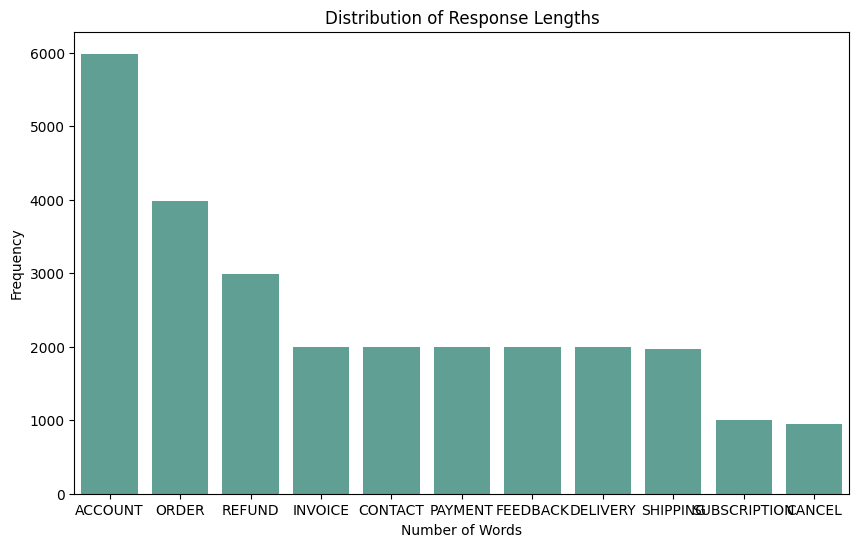

In [203]:
plt.figure(figsize=(10, 6))
sns.barplot(x=df['category'].value_counts().index, y=df['category'].value_counts().values)
plt.title('Distribution of Response Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

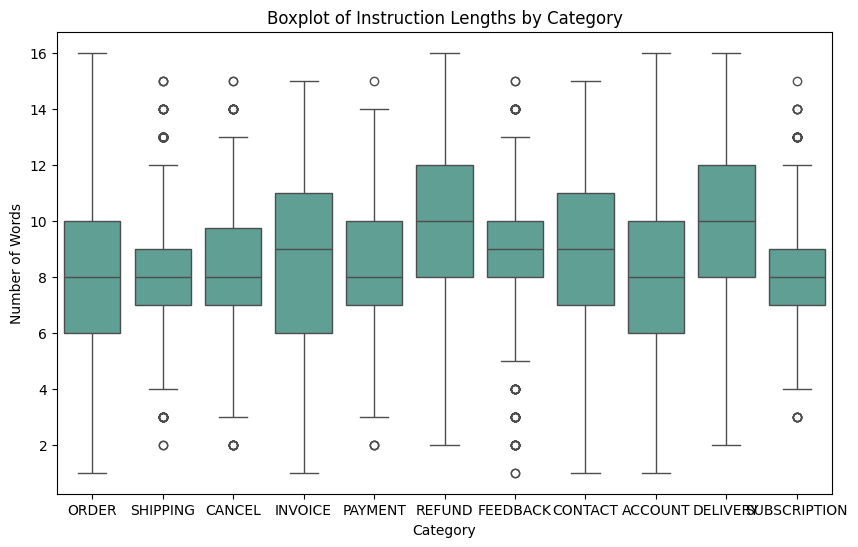

<Figure size 640x480 with 0 Axes>

In [204]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['category'], y=df['instruction'].str.split().apply(len))
plt.title('Boxplot of Instruction Lengths by Category')
plt.xlabel('Category')
plt.ylabel('Number of Words')   
plt.show()
plt.tight_layout()

Text(0, 0.5, 'Response Length (Number of Words)')

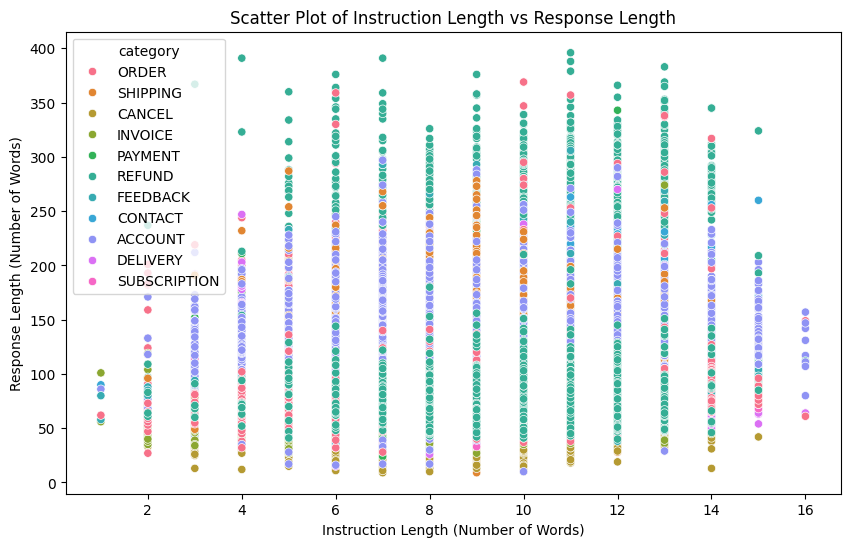

In [205]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['instruction'].str.split().apply(len), y=df['response'].str.split().apply(len), hue=df['category'])
plt.title('Scatter Plot of Instruction Length vs Response Length')
plt.xlabel('Instruction Length (Number of Words)')
plt.ylabel('Response Length (Number of Words)')

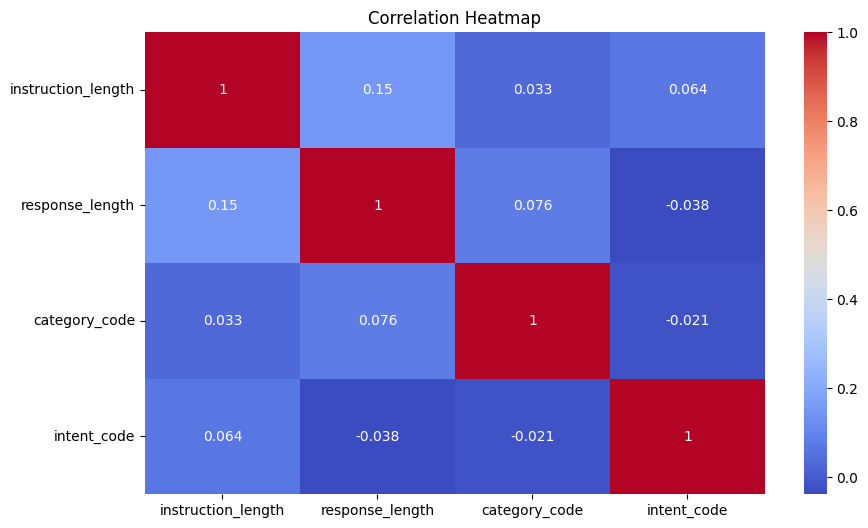

<Figure size 640x480 with 0 Axes>

In [206]:
plt.figure(figsize=(10,6))


sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()
plt.tight_layout()

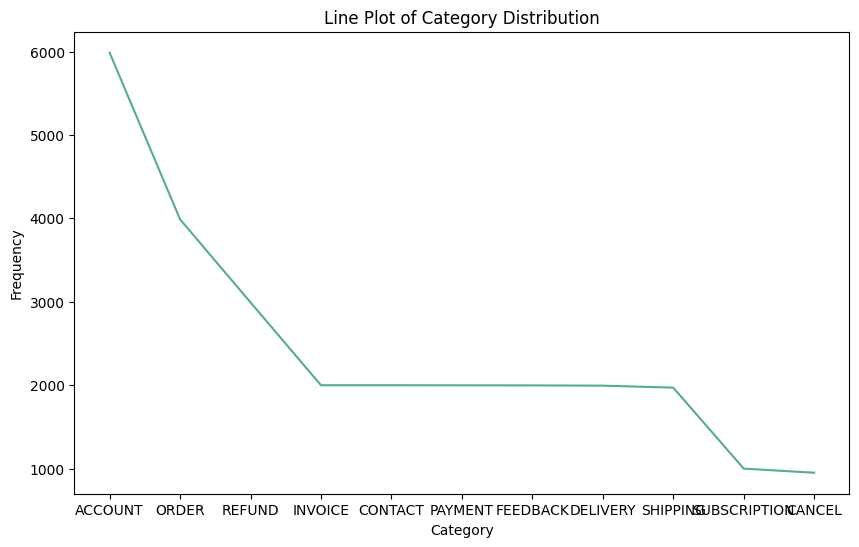

<Figure size 640x480 with 0 Axes>

In [207]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df['category'].value_counts().index, y=df['category'].value_counts().values)
plt.title('Line Plot of Category Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()
plt.tight_layout()

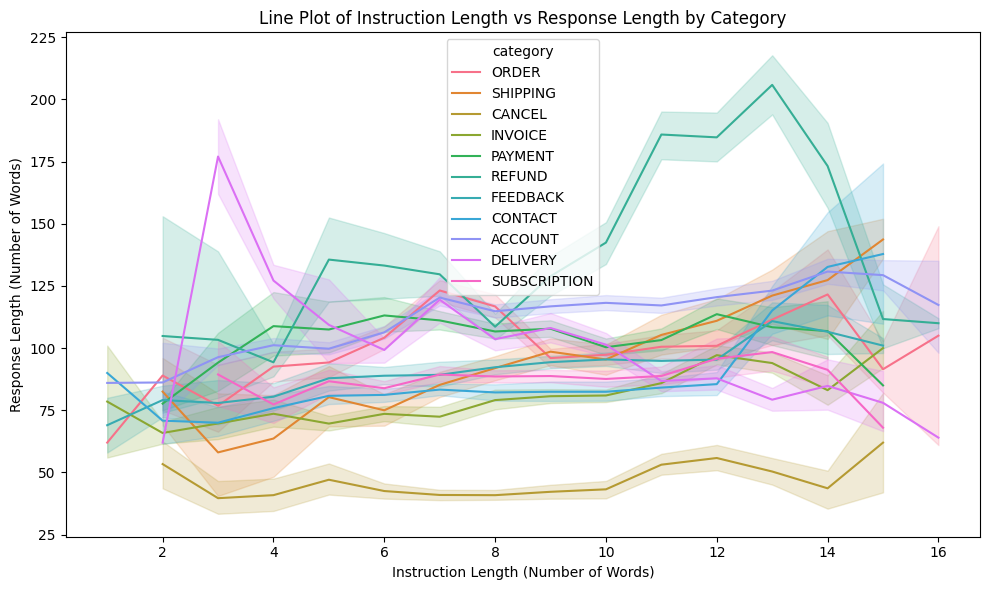

In [208]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df['instruction'].str.split().apply(len), y=df['response'].str.split().apply(len), hue=df['category'])
plt.title('Line Plot of Instruction Length vs Response Length by Category')
plt.xlabel('Instruction Length (Number of Words)')
plt.ylabel('Response Length (Number of Words)')
plt.tight_layout()
plt.show()

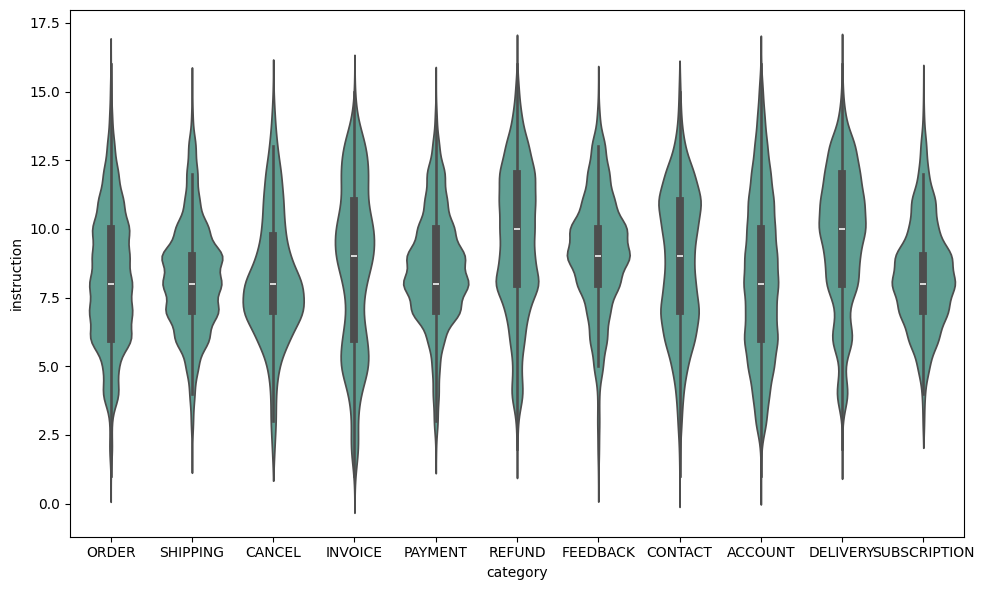

In [209]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['category'], y=df['instruction'].str.split().apply(len))

plt.tight_layout()
plt.show()

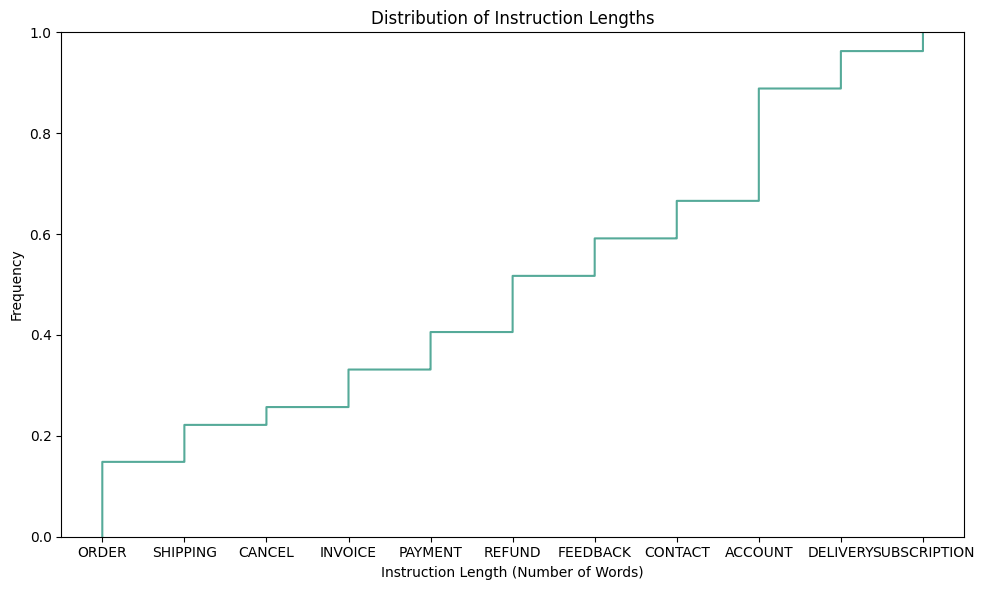

In [210]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(x=df['category'], data = df)
plt.xlabel('Instruction Length (Number of Words)')
plt.ylabel('Frequency')
plt.title('Distribution of Instruction Lengths')
plt.tight_layout()
plt.show()

In [211]:
# Input feature
x = df["instruction"]

# Target label
y = df["intent"]

print("Input samples:", len(X))
print("Number of intent classes:", y.nunique())

Input samples: 26872
Number of intent classes: 27


In [212]:
print("Number of unique intents:", y.nunique())

print("\nIntent classes:")
print(y.unique())

Number of unique intents: 27

Intent classes:
['cancel_order' 'change_order' 'change_shipping_address'
 'check_cancellation_fee' 'check_invoice' 'check_payment_methods'
 'check_refund_policy' 'complaint' 'contact_customer_service'
 'contact_human_agent' 'create_account' 'delete_account'
 'delivery_options' 'delivery_period' 'edit_account' 'get_invoice'
 'get_refund' 'newsletter_subscription' 'payment_issue' 'place_order'
 'recover_password' 'registration_problems' 'review'
 'set_up_shipping_address' 'switch_account' 'track_order' 'track_refund']


In [213]:
# Correct initial split using the original feature/target series
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Split the remaining training set into train/validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1875,
    random_state=42,
    stratify=y_train
)

print("Training:", len(x_train))
print("Validation:", len(x_val))
print("Testing:", len(x_test))

print("Training:", len(x_train))
print("Validation:", len(x_val))
print("Testing:", len(x_test))

Training: 15283
Validation: 3527
Testing: 8062
Training: 15283
Validation: 3527
Testing: 8062


#Tokenization

In [214]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000  # Maximum number of words to keep, based on word frequency
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

In [215]:
tokenizer.fit_on_texts(x_train)

In [216]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 2067


In [217]:
sample_text = x_train.iloc[0]
print("Sample text:", sample_text)
print("Tokenized:", tokenizer.texts_to_sequences([sample_text]))

Sample text: assistance speaking to someone
Tokenized: [[18, 277, 3, 259]]


In [218]:
x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [219]:
sequence_lengths = [len(seq) for seq in x_train_seq]
print("Max sequence length:", max(sequence_lengths))
print("Min sequence length:", min(sequence_lengths))
print("Average sequence length:", sum(sequence_lengths) / len(sequence_lengths))
print("Median sequence length:", np.median(sequence_lengths))

Max sequence length: 16
Min sequence length: 1
Average sequence length: 8.657397107897664
Median sequence length: 9.0


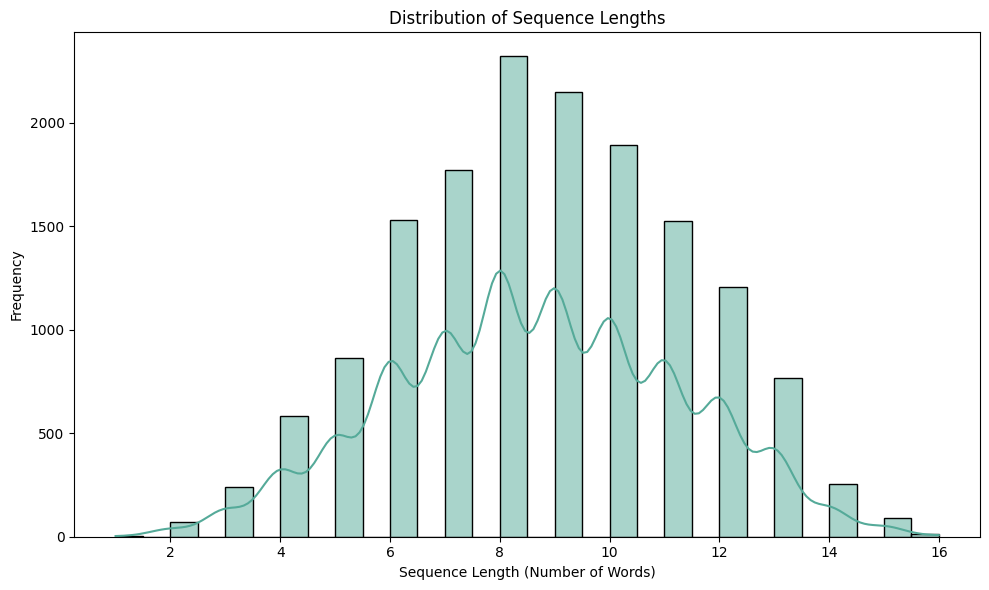

In [220]:
plt.figure(figsize=(10, 6))
sns.histplot(sequence_lengths, bins=30, kde=True)
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length (Number of Words)')
plt.ylabel('Frequency') 
plt.tight_layout()
plt.show()

#Padding

In [221]:
Max_length = 30
x_train_padded = pad_sequences(x_train_seq, maxlen=Max_length, padding='post', truncating='post')
x_val_padded = pad_sequences(x_val_seq, maxlen=Max_length, padding='post', truncating='post')

x_test_padded = pad_sequences(x_test_seq, maxlen=Max_length, padding='post', truncating='post')

In [222]:
print("Training padded shape:", x_train_padded.shape)
print("Validation padded shape:", x_val_padded.shape)
print("Testing padded shape:", x_test_padded.shape)

Training padded shape: (15283, 30)
Validation padded shape: (3527, 30)
Testing padded shape: (8062, 30)


In [223]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

In [224]:
print('first 5 encoded labels:', y_train_encoded[:5])

first 5 encoded labels: [ 9 25 22 10  6]


In [225]:
for i in range(5):
    print(f"Sample {i+1}:")
    print("Instruction:", x_train.iloc[i])
    print("Intent:", y_train.iloc[i])
    print() 

Sample 1:
Instruction: assistance speaking to someone
Intent: contact_human_agent

Sample 2:
Instruction: how to check the eta of order order number
Intent: track_order

Sample 3:
Instruction: i need assistance leaving feedback for a product
Intent: review

Sample 4:
Instruction: another account type account for father
Intent: create_account

Sample 5:
Instruction: how can i check your reimbursement policy
Intent: check_refund_policy



In [226]:
Num_Classes = len(label_encoder.classes_)
print("Number of unique intent classes:", Num_Classes)

Number of unique intent classes: 27


#ANN Model

In [227]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128

In [228]:
print("Vocabulary size:", VOCAB_SIZE)
print("Embedding dimension:", EMBEDDING_DIM)
print("Number of classes:", Num_Classes)

Vocabulary size: 2068
Embedding dimension: 128
Number of classes: 27


In [229]:
ann_model = Sequential([
    Embedding(
        input_dim = VOCAB_SIZE,
        output_dim = EMBEDDING_DIM,
        input_length = Max_length
    ),
    GlobalAveragePooling1D(),
    Dense(128, activation ='relu'),
    Dropout(0.4),
    Dense(64, activation ='relu'),
    Dropout(0.3),
    Dense(Num_Classes, activation ='softmax')
    
])

/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [230]:
ann_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [232]:
ann_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [231]:
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau


In [233]:
early_Stop = EarlyStopping(
    monitor='val_loss',
    patience= 3,
    restore_best_weights= True
    
)
reduce_lr = ReduceLROnPlateau(
    monitor= 'val_loss',
    patience= 2,
    factor=0.5,
    min_lr=1e-6
)

In [236]:
history_ann = ann_model.fit(
    x_train_padded,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_padded, y_val_encoded),
    callbacks=[early_Stop, reduce_lr]
)

Epoch 1/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9965 - loss: 0.0116 - val_accuracy: 0.9932 - val_loss: 0.0265 - learning_rate: 1.2500e-04
Epoch 2/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9973 - loss: 0.0101 - val_accuracy: 0.9946 - val_loss: 0.0207 - learning_rate: 1.2500e-04
Epoch 3/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9965 - loss: 0.0115 - val_accuracy: 0.9943 - val_loss: 0.0244 - learning_rate: 1.2500e-04
Epoch 4/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9961 - loss: 0.0120 - val_accuracy: 0.9938 - val_loss: 0.0222 - learning_rate: 1.2500e-04
Epoch 5/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9980 - loss: 0.0098 - val_accuracy: 0.9940 - val_loss: 0.0211 - learning_rate: 6.2500e-05


In [237]:
test_loss, test_accuracy = ann_model.evaluate(x_test_padded, y_test_encoded)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.9950 - loss: 0.0160
Test Loss: 0.0160
Test Accuracy: 0.9950


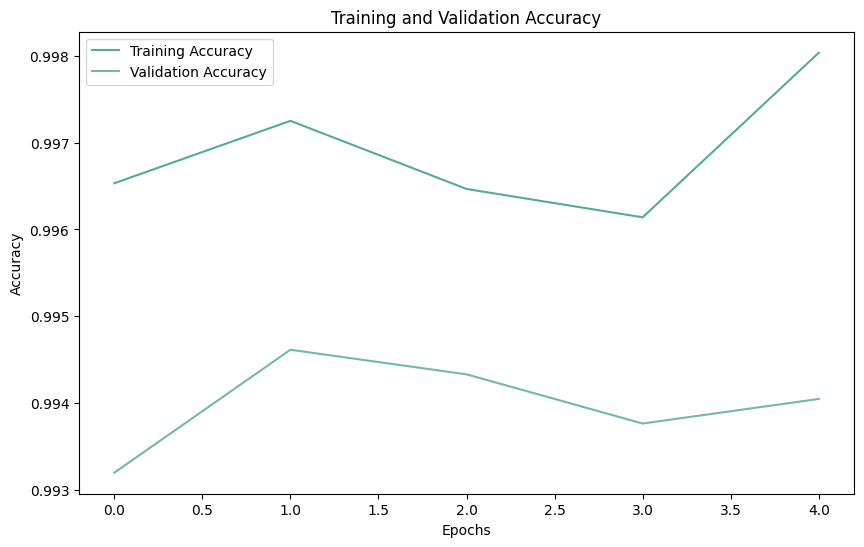

In [238]:
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

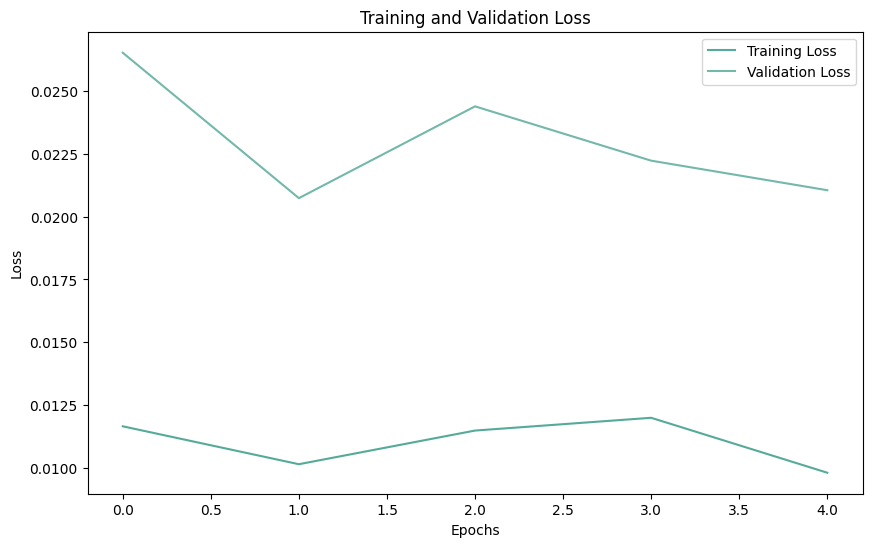

<Figure size 640x480 with 0 Axes>

In [239]:
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')  
plt.legend()
plt.show()
plt.tight_layout()

In [240]:
y_pred_probs = ann_model.predict(x_test_padded)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step


In [241]:
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

In [242]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))
print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print("Precision:", precision_score(y_test_labels, y_pred_labels, average='weighted'))
print("Recall:", recall_score(y_test_labels, y_pred_labels, average='weighted'))
print("F1 Score:", f1_score(y_test_labels, y_pred_labels, average='weighted'))

Classification Report:
                          precision    recall  f1-score   support

            cancel_order       0.98      1.00      0.99       299
            change_order       1.00      0.99      0.99       299
 change_shipping_address       0.99      0.99      0.99       292
  check_cancellation_fee       0.99      1.00      1.00       285
           check_invoice       0.98      0.99      0.99       300
   check_payment_methods       1.00      1.00      1.00       300
     check_refund_policy       1.00      1.00      1.00       299
               complaint       1.00      1.00      1.00       300
contact_customer_service       1.00      0.99      1.00       300
     contact_human_agent       0.99      1.00      1.00       300
          create_account       0.99      0.98      0.98       299
          delete_account       0.99      1.00      0.99       299
        delivery_options       1.00      1.00      1.00       298
         delivery_period       1.00      1.00      1

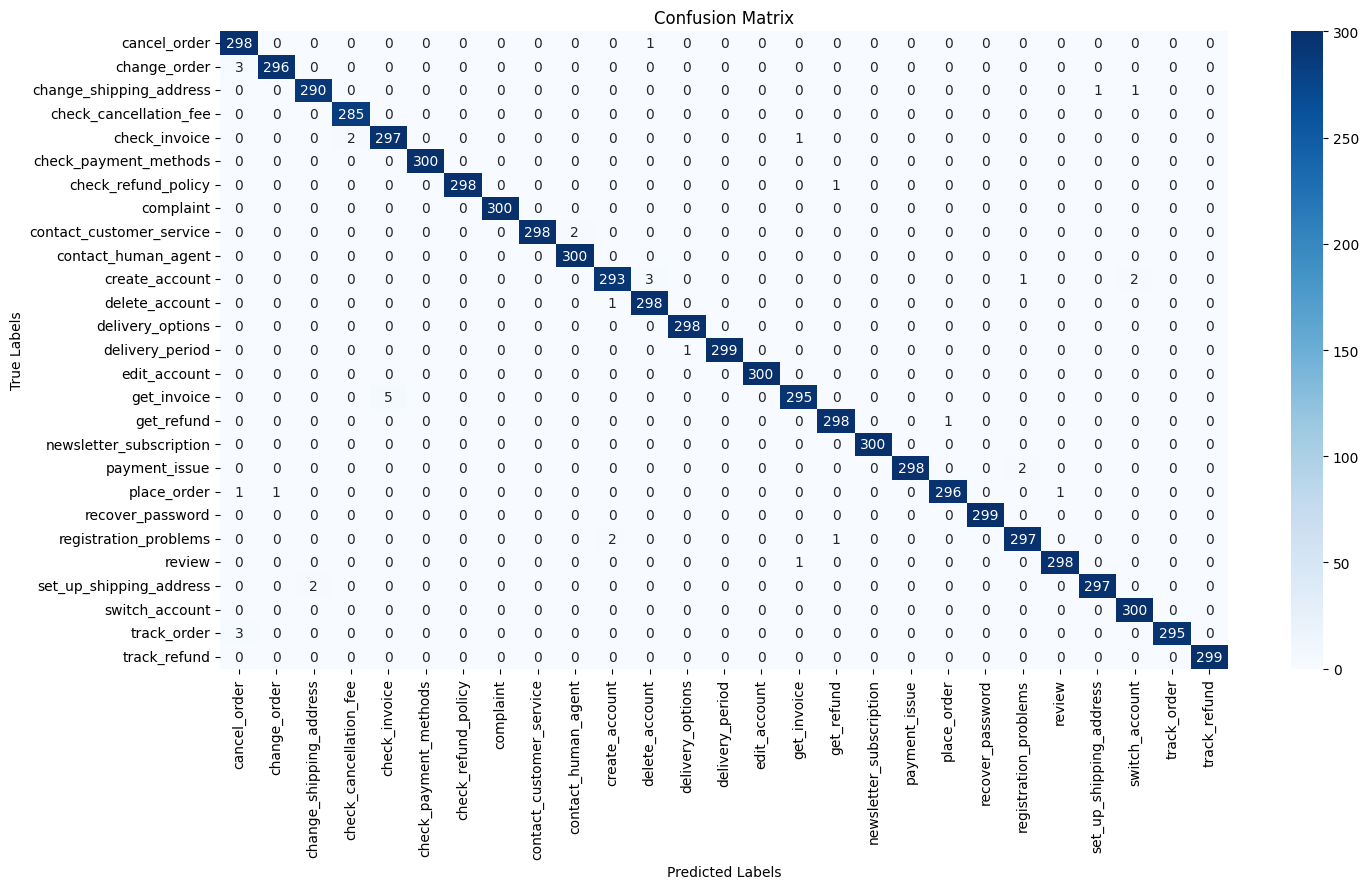

In [245]:
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(15, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


#LSTM MODEL

In [251]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [258]:

from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau
early_Stop = EarlyStopping(
    monitor='val_loss',
    patience= 3,
    restore_best_weights= True
)
reduce_lr = ReduceLROnPlateau(
    monitor= 'val_loss',
    patience= 2,
    factor=0.5,
    min_lr=1e-6
)
LSTM_MODEL = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=Max_length
    ),
    LSTM(128),  # return_sequences=False by default
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(Num_Classes, activation='softmax')
])

LSTM_MODEL.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


early_Stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    min_lr=1e-6
)

history_lstm = LSTM_MODEL.fit(
    x_train_padded,
    y_train_encoded,
    epochs=20, 
    batch_size=32,
    validation_data=(x_val_padded, y_val_encoded),
    callbacks=[early_Stop, reduce_lr]
)

Epoch 1/20


/opt/homebrew/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


478/478 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.0945 - loss: 2.8941 - val_accuracy: 0.2124 - val_loss: 1.9949 - learning_rate: 0.0010
Epoch 2/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.2884 - loss: 1.7266 - val_accuracy: 0.4460 - val_loss: 1.2229 - learning_rate: 0.0010
Epoch 3/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4652 - loss: 1.1667 - val_accuracy: 0.5588 - val_loss: 0.9712 - learning_rate: 0.0010
Epoch 4/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6085 - loss: 0.8232 - val_accuracy: 0.7065 - val_loss: 0.5880 - learning_rate: 0.0010
Epoch 5/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7553 - loss: 0.5286 - val_accuracy: 0.8494 - val_loss: 0.3557 - learning_rate: 0.0010
Epoch 6/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8854 - loss: 0.3209 - val_accuracy: 0.9229 - val_loss: 0.3745 - learning_rate: 0.0010
Epoch 7/20
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9472 - loss: 0.1805 

In [259]:
test_loss_lstm, test_accuracy_lstm = LSTM_MODEL.evaluate(x_test_padded, y_test_encoded)
print(f"Test Loss (LSTM): {test_loss_lstm:.4f}")
print(f"Test Accuracy (LSTM): {test_accuracy_lstm:.4f}")  


252/252 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9857 - loss: 0.0896
Test Loss (LSTM): 0.0896
Test Accuracy (LSTM): 0.9857


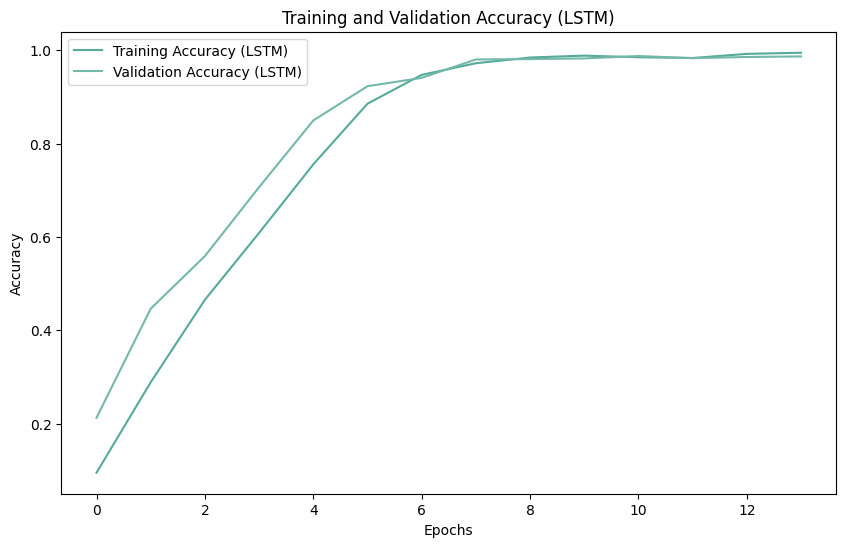

In [261]:
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy (LSTM)')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy (LSTM)')
plt.title('Training and Validation Accuracy (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()    
plt.show()

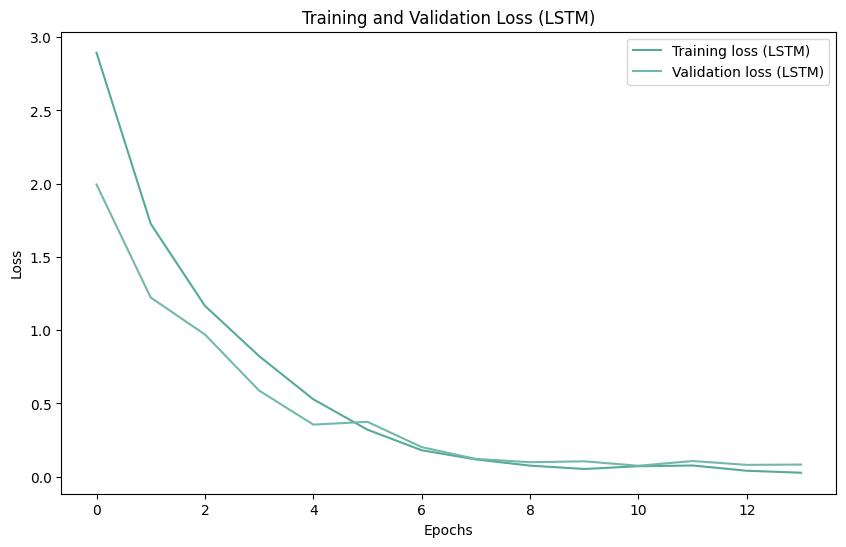

In [262]:
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Training loss (LSTM)')
plt.plot(history_lstm.history['val_loss'], label='Validation loss (LSTM)')
plt.title('Training and Validation Loss (LSTM)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [260]:
y_pred_probs = ann_model.predict(x_test_padded)
y_pred_classes = np.argmax(y_pred_probs, axis=1)    
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

252/252 ━━━━━━━━━━━━━━━━━━━━ 0s 490us/step


In [263]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Classification Report:")
print(classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:")
print(confusion_matrix(y_test_labels, y_pred_labels))
print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print("Precision:", precision_score(y_test_labels, y_pred_labels, average='weighted'))
print("Recall:", recall_score(y_test_labels, y_pred_labels, average='weighted'))    
print("F1 Score:", f1_score(y_test_labels, y_pred_labels, average='weighted'))


Classification Report:
                          precision    recall  f1-score   support

            cancel_order       0.98      1.00      0.99       299
            change_order       1.00      0.99      0.99       299
 change_shipping_address       0.99      0.99      0.99       292
  check_cancellation_fee       0.99      1.00      1.00       285
           check_invoice       0.98      0.99      0.99       300
   check_payment_methods       1.00      1.00      1.00       300
     check_refund_policy       1.00      1.00      1.00       299
               complaint       1.00      1.00      1.00       300
contact_customer_service       1.00      0.99      1.00       300
     contact_human_agent       0.99      1.00      1.00       300
          create_account       0.99      0.98      0.98       299
          delete_account       0.99      1.00      0.99       299
        delivery_options       1.00      1.00      1.00       298
         delivery_period       1.00      1.00      1

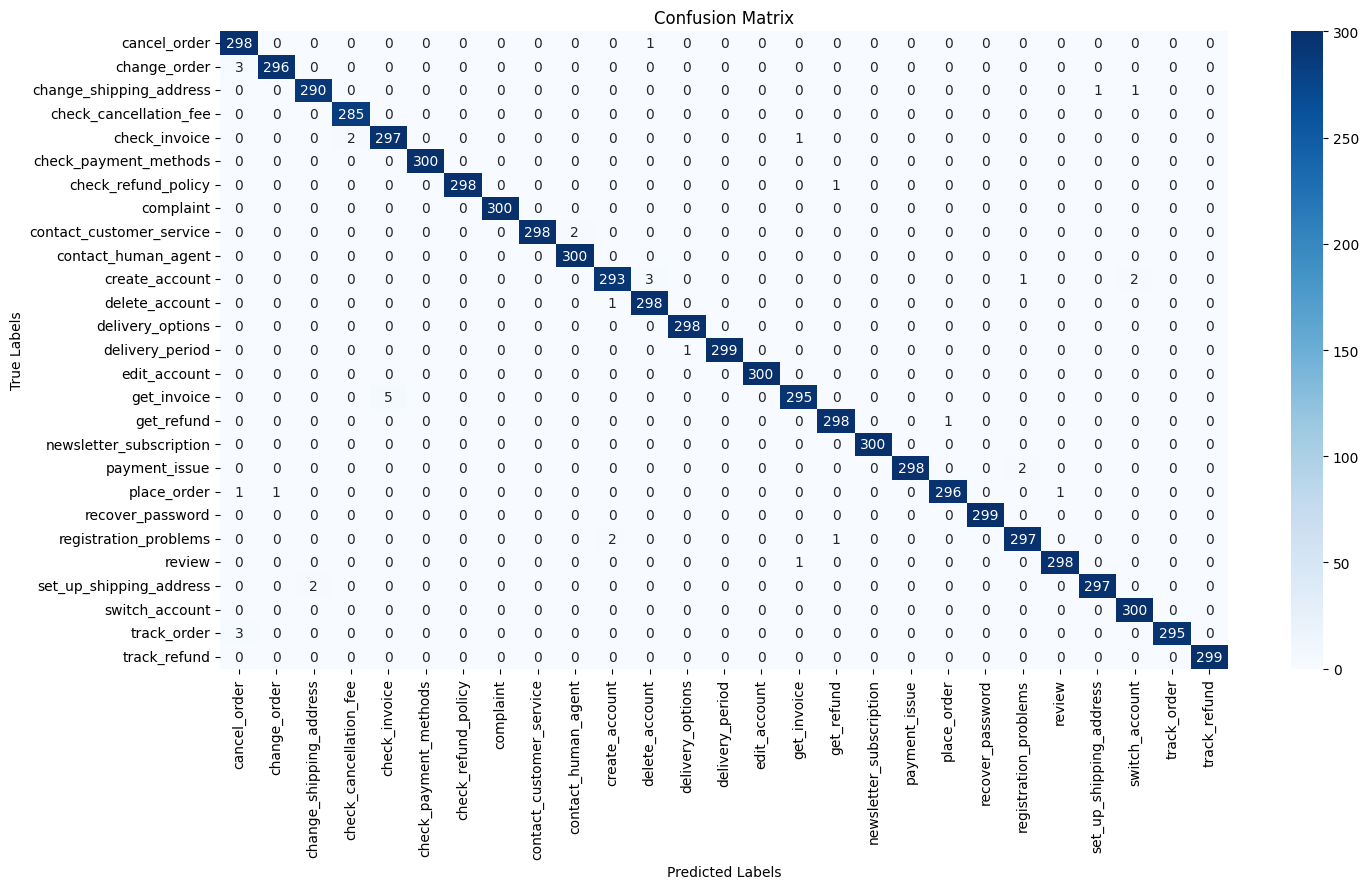

In [268]:
cm = confusion_matrix(y_test_labels, y_pred_labels)
plt.figure(figsize=(15, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


In [274]:
# Compare model accuracies
model_scores = {
    "ANN": test_accuracy,
    "LSTM": test_accuracy_lstm
}

best_model_name = max(
    model_scores,
    key=model_scores.get
)

best_accuracy = model_scores[best_model_name]

print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print("Model:", best_model_name)
print(f"Test Accuracy: {best_accuracy:.4f}")
print("=" * 50)

BEST MODEL
Model: ANN
Test Accuracy: 0.9950


In [275]:
if best_model_name == "ANN":
    best_model = ann_model
else:
    best_model = LSTM_MODEL

best_model.save("SupportSense_best_model.keras")

print("Best model saved successfully!")

Best model saved successfully!


In [276]:
import pickle

with open("SupportSense_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [277]:
with open("SupportSense_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved successfully!")

Label encoder saved successfully!


In [278]:
config = {
    "max_length": Max_length,
    "vocab_size": VOCAB_SIZE,
    "num_classes": Num_Classes,
    "embedding_dim": EMBEDDING_DIM
}

with open("SupportSense_config.pkl", "wb") as f:
    pickle.dump(config, f)

print("Configuration saved successfully!")

Configuration saved successfully!


In [279]:
from tensorflow.keras.models import load_model
import pickle

loaded_model = load_model(
    "SupportSense_best_model.keras"
)

with open("SupportSense_tokenizer.pkl", "rb") as f:
    loaded_tokenizer = pickle.load(f)

with open("SupportSense_label_encoder.pkl", "rb") as f:
    loaded_label_encoder = pickle.load(f)

print("Model loaded successfully!")
print("Tokenizer loaded successfully!")
print("Label encoder loaded successfully!")

Model loaded successfully!
Tokenizer loaded successfully!
Label encoder loaded successfully!


In [283]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_intent(text):
    
    # Convert text to sequence
    sequence = loaded_tokenizer.texts_to_sequences([text])
    
    # Pad sequence
    padded_sequence = pad_sequences(
        sequence,
        maxlen=Max_length,
        padding="post",
        truncating="post"
    )
    
    # Prediction
    probabilities = loaded_model.predict(
        padded_sequence,
        verbose=0
    )
    
    # Get predicted class
    predicted_class = probabilities.argmax(axis=1)[0]
    
    # Convert class number to intent
    predicted_intent = loaded_label_encoder.inverse_transform(
        [predicted_class]
    )[0]
    
    # Confidence
    confidence = probabilities[0][predicted_class]
    
    return predicted_intent, confidence

In [284]:
queries = [
    "Why was my card payment declined?",
    "I want to cancel my transfer",
    "How can I change my PIN?",
    "My cash withdrawal failed",
    "I don't recognize this transaction"
]

for query in queries:
    
    intent, confidence = predict_intent(query)
    
    print("-" * 60)
    print("Query:", query)
    print("Intent:", intent)
    print(f"Confidence: {confidence:.2%}")

------------------------------------------------------------
Query: Why was my card payment declined?
Intent: payment_issue
Confidence: 98.77%
------------------------------------------------------------
Query: I want to cancel my transfer
Intent: delete_account
Confidence: 99.89%
------------------------------------------------------------
Query: How can I change my PIN?
Intent: recover_password
Confidence: 99.68%
------------------------------------------------------------
Query: My cash withdrawal failed
Intent: check_cancellation_fee
Confidence: 75.49%
------------------------------------------------------------
Query: I don't recognize this transaction
Intent: registration_problems
Confidence: 43.72%
